# 压缩策略结果分析

比较四种策略在 Qwen3.5 系列模型上的表现：
- **No Compression**：完整历史上下文
- **Summary**：摘要压缩
- **SLSC w/o Formal**：结构化状态压缩（无 Lean4 形式化）
- **SLSC (ours)**：结构化状态压缩 + Lean4 形式化

数据来源：`results_v6_100t/`

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120

RESULTS_DIR = Path("/root/autodl-tmp/Formal_compress/results_v6_100t")

MODES = ["no_compression", "summary", "slsc_no_formal", "slsc"]
MODE_LABELS = {
    "no_compression": "No Compression",
    "summary":        "Summary",
    "slsc_no_formal": "SLSC w/o Formal",
    "slsc":           "SLSC (ours)",
}
MODE_COLORS = {
    "no_compression": "#9C27B0",
    "summary":        "#FF9800",
    "slsc_no_formal": "#4CAF50",
    "slsc":           "#2196F3",
}
VERDICT_COLORS = {
    "correct":          "#4CAF50",
    "partially_correct":"#FF9800",
    "incorrect":        "#F44336",
}

In [2]:
def load_jsonl(path):
    with open(path, encoding="utf-8") as f:
        return [json.loads(l) for l in f if l.strip()]

def mode_from_stem(stem):
    if "_slsc_no_formal_judged" in stem: return "slsc_no_formal"
    if "_summary_judged"        in stem: return "summary"
    if "_slsc_judged"           in stem: return "slsc"
    if "_model_judged"          in stem: return "no_compression"
    if "_slsc_no_formal"        in stem: return "slsc_no_formal"
    if stem.endswith("_summary"):        return "summary"
    if stem.endswith("_slsc"):           return "slsc"
    if stem.endswith("_model"):          return "no_compression"
    return "unknown"

def model_from_stem(stem):
    for suf in ("_slsc_no_formal_judged","_summary_judged","_slsc_judged","_model_judged",
                "_slsc_no_formal","_summary","_slsc","_model"):
        if stem.endswith(suf):
            return stem[:-len(suf)]
    return stem

# ── judged files → accuracy data ──────────────────────────────────────────
prob_rows, turn_rows = [], []
for path in sorted(RESULTS_DIR.glob("*_judged.jsonl")):
    model = model_from_stem(path.stem)
    mode  = mode_from_stem(path.stem)
    if mode not in MODES: continue
    for item in load_jsonl(path):
        n = item["num_turns"]
        cat = item["problem_id"].split("/")[-2] if "/" in item["problem_id"] else "unknown"
        prob_rows.append({
            "model": model, "mode": mode,
            "problem_id": item["problem_id"], "category": cat,
            "all_correct": item["all_correct"],
            "num_correct": item["num_correct"],
            "num_turns": n,
            "score": item["num_correct"] / n,
        })
        for t in item["turns"]:
            turn_rows.append({
                "model": model, "mode": mode,
                "problem_id": item["problem_id"], "category": cat,
                "turn": t["turn"],
                "verdict": t.get("verdict", "unknown"),
                "is_correct": t.get("is_correct", False),
            })

df_prob = pd.DataFrame(prob_rows)
df_turn = pd.DataFrame(turn_rows)

# ── raw eval files → token data ───────────────────────────────────────────
tok_rows, ttok_rows = [], []
for path in sorted(RESULTS_DIR.glob("*.jsonl")):
    if "_judged" in path.stem: continue
    model = model_from_stem(path.stem)
    mode  = mode_from_stem(path.stem)
    if mode not in MODES: continue
    for item in load_jsonl(path):
        tok_rows.append({
            "model": model, "mode": mode,
            "problem_id": item["problem_id"],
            "total_input_tokens":          item.get("total_input_tokens"),
            "total_agent_a_input_tokens":  item.get("total_agent_a_input_tokens"),
            "total_agent_a_output_tokens": item.get("total_agent_a_output_tokens"),
            "total_agent_b_input_tokens":  item.get("total_agent_b_input_tokens"),
            "total_agent_b_output_tokens": item.get("total_agent_b_output_tokens"),
            "total_combined_tokens":       item.get("total_combined_tokens"),
        })
        for t in item["turns"]:
            ttok_rows.append({
                "model": model, "mode": mode,
                "problem_id": item["problem_id"],
                "turn": t["turn"],
                "input_tokens": t.get("agent_a_input_tokens"),
                "state_tokens": t.get("state_tokens"),
            })

df_tok  = pd.DataFrame(tok_rows)
df_ttok = pd.DataFrame(ttok_rows)

MODELS = sorted(df_prob["model"].unique())
print(f"Models : {MODELS}")
print(f"Modes  : {df_prob['mode'].unique().tolist()}")
print(f"Problems: {len(df_prob)} rows  |  Turns: {len(df_turn)} rows")

Models : ['Qwen3.5-0.8B', 'Qwen3.5-2B', 'Qwen3.5-4B', 'Qwen3.5-9B']
Modes  : ['no_compression', 'slsc', 'slsc_no_formal', 'summary']
Problems: 1599 rows  |  Turns: 5101 rows


## 1. 整体准确率对比

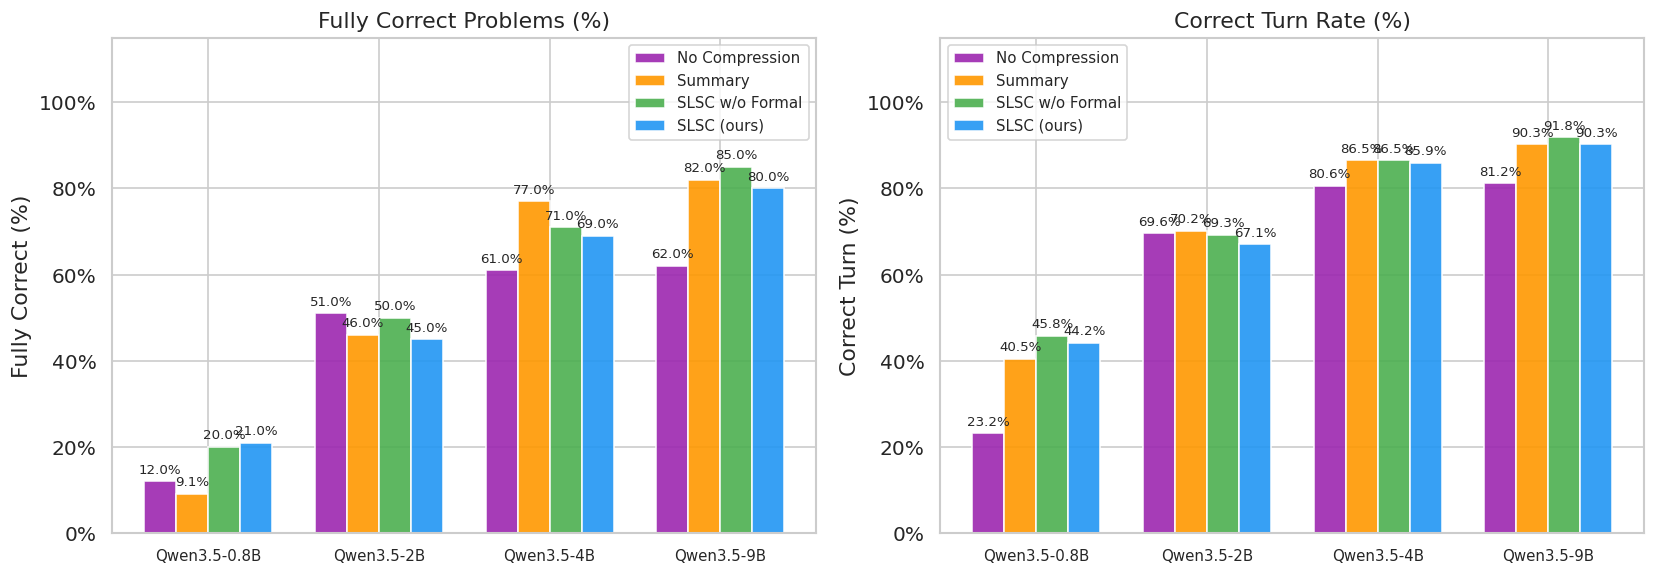

,No Compression,SLSC (ours),SLSC w/o Formal,Summary,Δ SLSC (ours) − NC
Model,,,,,
Qwen3.5-0.8B,12.0,21.0,20.0,9.1,9.0
Qwen3.5-2B,51.0,45.0,50.0,46.0,-6.0
Qwen3.5-4B,61.0,69.0,71.0,77.0,8.0
Qwen3.5-9B,62.0,80.0,85.0,82.0,18.0


In [3]:
n_modes  = len(MODES)
n_models = len(MODELS)
x        = np.arange(n_models)
width    = 0.75 / n_modes

# ── compute ────────────────────────────────────────────────────────────────
acc = (
    df_prob.groupby(["model","mode"])
    .agg(n=("problem_id","count"), fc=("all_correct","sum"))
    .assign(fc_pct=lambda d: d["fc"]/d["n"]*100)
    .reset_index()
)
turn_acc = (
    df_turn.groupby(["model","mode"])["is_correct"]
    .agg(pct=lambda s: s.mean()*100)
    .reset_index()
)

# ── chart ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, df_src, col, title, ylabel in [
    (axes[0], acc,      "fc_pct", "Fully Correct Problems (%)", "Fully Correct (%)"),
    (axes[1], turn_acc, "pct",    "Correct Turn Rate (%)",      "Correct Turn (%)"),
]:
    for i, mode in enumerate(MODES):
        sub = df_src[df_src["mode"]==mode].set_index("model")
        offset = (i - (n_modes-1)/2) * width
        vals = [sub.loc[m, col] if m in sub.index else 0 for m in MODELS]
        bars = ax.bar(x+offset, vals, width,
                      label=MODE_LABELS[mode], color=MODE_COLORS[mode],
                      edgecolor="white", alpha=0.9)
        ax.bar_label(bars, fmt="%.1f%%", padding=3, fontsize=8)
    ax.set_xticks(x); ax.set_xticklabels(MODELS, fontsize=9)
    ax.set_ylabel(ylabel); ax.set_ylim(0, 115)
    ax.set_title(title)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter())
    ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

# ── table ──────────────────────────────────────────────────────────────────
tbl = acc.pivot_table(index="model", columns="mode", values="fc_pct")
tbl.columns = [MODE_LABELS[c] for c in tbl.columns]
tbl.index.name = "Model"
nc = MODE_LABELS["no_compression"]
slsc_col = MODE_LABELS["slsc"]
if slsc_col in tbl.columns:
    tbl[f"Δ {slsc_col} − NC"] = tbl[slsc_col] - tbl[nc]
display(tbl.round(1))

## 2. Verdict 分布（各模型 × 各模式）

/tmp/ipykernel_171786/2109902287.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(piv.index, rotation=20, ha="right", fontsize=8)
/tmp/ipykernel_171786/2109902287.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(piv.index, rotation=20, ha="right", fontsize=8)
/tmp/ipykernel_171786/2109902287.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(piv.index, rotation=20, ha="right", fontsize=8)
/tmp/ipykernel_171786/2109902287.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(piv.index, rotation=20, ha="right", fontsize=8)


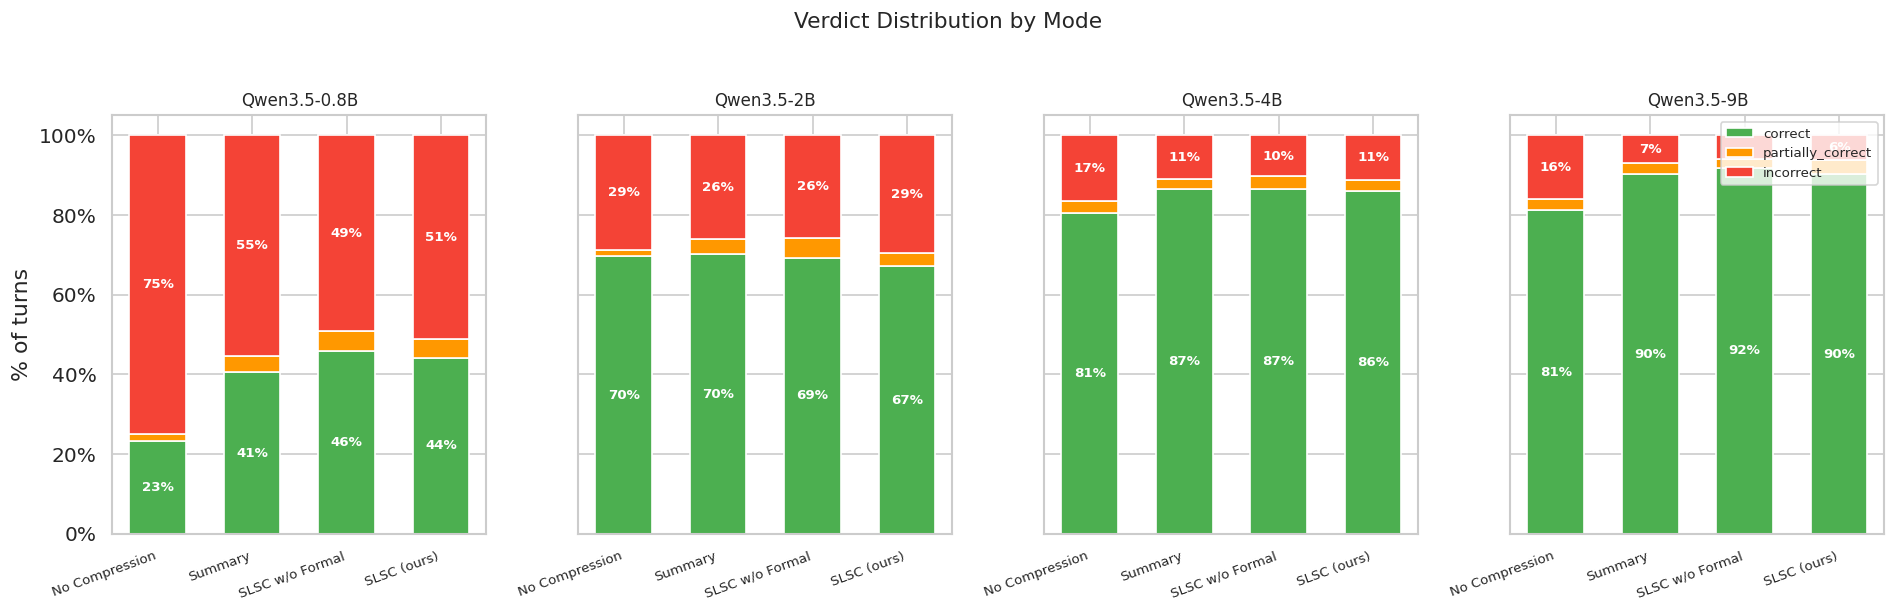

verdict                       correct  partially_correct  incorrect
Model        Mode                                                  
Qwen3.5-0.8B No Compression      23.2                1.9       74.9
             SLSC (ours)         44.2                4.7       51.1
             SLSC w/o Formal     45.8                5.0       49.2
             Summary             40.5                4.1       55.4
Qwen3.5-2B   No Compression      69.6                1.6       28.8
             SLSC (ours)         67.1                3.4       29.5
             SLSC w/o Formal     69.3                5.0       25.7
             Summary             70.2                3.8       26.0
Qwen3.5-4B   No Compression      80.6                2.8       16.6
             SLSC (ours)         85.9                2.8       11.3
             SLSC w/o Formal     86.5                3.1       10.3
             Summary             86.5                2.5       11.0
Qwen3.5-9B   No Compression      81.2                2.8       16.0
             SLSC (ours)         90.3                3.4        6.3
             SLSC w/o Formal     91.8                2.2        6.0
             Summary             90.3                2.8        6.9

In [4]:
VERDICT_ORDER = ["correct","partially_correct","incorrect"]

vd = (
    df_turn.groupby(["model","mode","verdict"]).size().reset_index(name="cnt")
)
vd_tot = df_turn.groupby(["model","mode"]).size().reset_index(name="tot")
vd = vd.merge(vd_tot, on=["model","mode"])
vd["pct"] = vd["cnt"] / vd["tot"] * 100

# ── chart ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, n_models, figsize=(4*n_models, 5), sharey=True)
if n_models == 1: axes = [axes]

for ax, model in zip(axes, MODELS):
    sub = vd[vd["model"]==model]
    piv = sub.pivot_table(index="mode", columns="verdict", values="pct", fill_value=0)
    for v in VERDICT_ORDER:
        if v not in piv.columns: piv[v] = 0
    piv = piv[VERDICT_ORDER].reindex([m for m in MODES if m in piv.index])
    piv.index = [MODE_LABELS[i] for i in piv.index]

    bottom = np.zeros(len(piv))
    for v in VERDICT_ORDER:
        vals = piv[v].values
        bars = ax.bar(piv.index, vals, bottom=bottom,
                      color=VERDICT_COLORS[v], label=v, edgecolor="white", width=0.6)
        for bar, val, bot in zip(bars, vals, bottom):
            if val > 6:
                ax.text(bar.get_x()+bar.get_width()/2, bot+val/2,
                        f"{val:.0f}%", ha="center", va="center",
                        fontsize=8, color="white", fontweight="bold")
        bottom += vals

    ax.set_title(model, fontsize=10)
    ax.set_ylabel("% of turns" if ax==axes[0] else "")
    ax.yaxis.set_major_formatter(mticker.PercentFormatter())
    ax.set_xticklabels(piv.index, rotation=20, ha="right", fontsize=8)
    if ax == axes[-1]:
        ax.legend(loc="upper right", fontsize=8)

plt.suptitle("Verdict Distribution by Mode", y=1.02, fontsize=13)
plt.tight_layout(); plt.show()

# ── table ──────────────────────────────────────────────────────────────────
tbl2 = (
    vd[vd["verdict"].isin(VERDICT_ORDER)]
    .pivot_table(index=["model","mode"], columns="verdict", values="pct", fill_value=0)
    [VERDICT_ORDER]
)
tbl2.index = pd.MultiIndex.from_tuples(
    [(m, MODE_LABELS[md]) for m, md in tbl2.index], names=["Model","Mode"]
)
display(tbl2.round(1))

## 3. 各 Turn 位置准确率

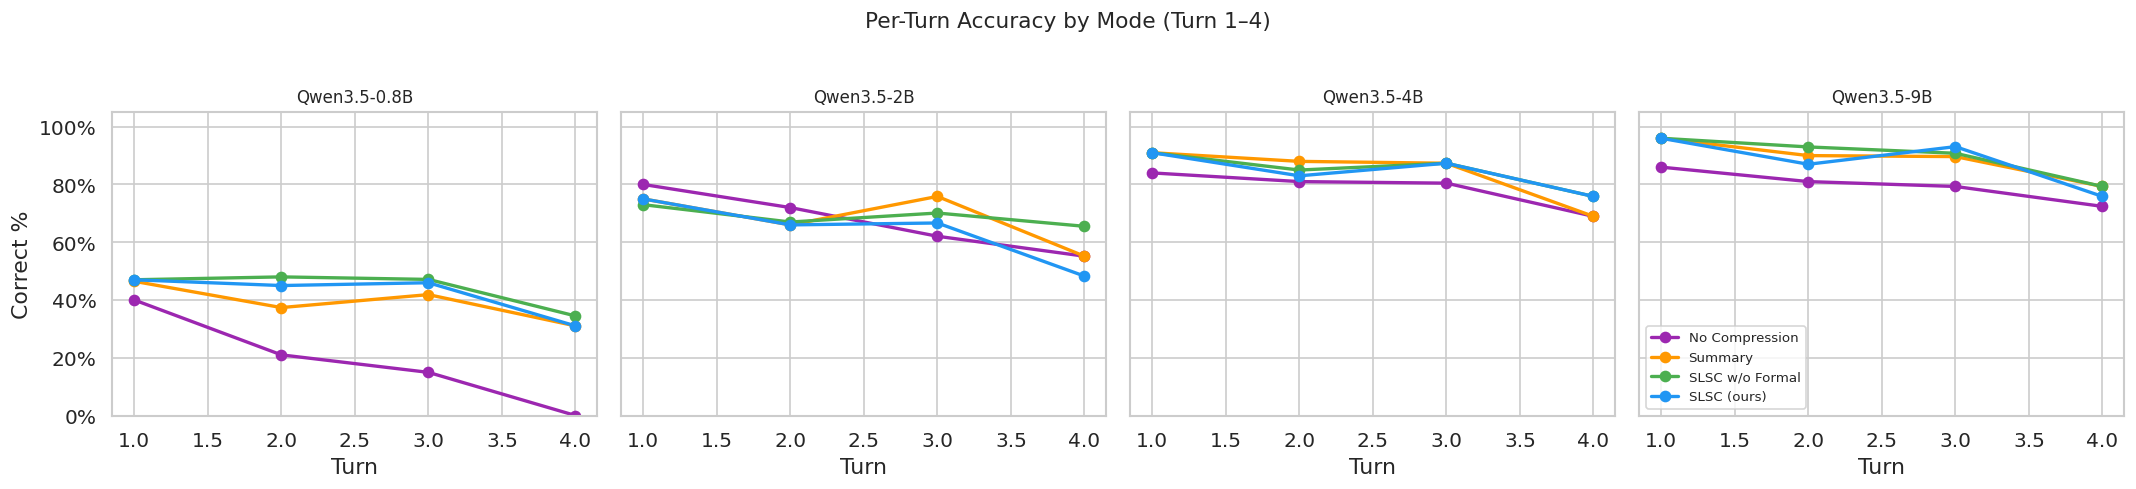

No Compression  SLSC (ours)  SLSC w/o Formal  Summary
Model        Turn                                                       
Qwen3.5-0.8B 1               40.0         47.0             47.0     46.5
             2               21.0         45.0             48.0     37.4
             3               14.9         46.0             47.1     41.9
             4                0.0         31.0             34.5     31.0
Qwen3.5-2B   1               80.0         75.0             73.0     75.0
             2               72.0         66.0             67.0     66.0
             3               62.1         66.7             70.1     75.9
             4               55.2         48.3             65.5     55.2
Qwen3.5-4B   1               84.0         91.0             91.0     91.0
             2               81.0         83.0             85.0     88.0
             3               80.5         87.4             87.4     87.4
             4               69.0         75.9             75.9     69.0
Qwen3.5-9B   1               86.0         96.0             96.0     96.0
             2               81.0         87.0             93.0     90.0
             3               79.3         93.1             90.8     89.7
             4               72.4         75.9             79.3     79.3

In [5]:
turn_pos = (
    df_turn[df_turn["turn"] <= 4]
    .groupby(["model","mode","turn"])["is_correct"]
    .agg(pct=lambda s: s.mean()*100)
    .reset_index()
)

# ── chart ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, n_models, figsize=(4.5*n_models, 4), sharey=True)
if n_models == 1: axes = [axes]

for ax, model in zip(axes, MODELS):
    sub = turn_pos[turn_pos["model"]==model]
    for mode in MODES:
        ms = sub[sub["mode"]==mode]
        if ms.empty: continue
        ax.plot(ms["turn"], ms["pct"], marker="o",
                label=MODE_LABELS[mode], color=MODE_COLORS[mode], linewidth=2)
    ax.set_title(model, fontsize=10)
    ax.set_xlabel("Turn")
    ax.set_ylabel("Correct %" if ax==axes[0] else "")
    ax.yaxis.set_major_formatter(mticker.PercentFormatter())
    ax.set_ylim(0, 105)
    if ax == axes[-1]: ax.legend(fontsize=8)

plt.suptitle("Per-Turn Accuracy by Mode (Turn 1–4)", y=1.02, fontsize=13)
plt.tight_layout(); plt.show()

# ── table ──────────────────────────────────────────────────────────────────
tbl3 = turn_pos.pivot_table(index=["model","turn"], columns="mode", values="pct")
tbl3.columns = [MODE_LABELS[c] for c in tbl3.columns]
tbl3.index.names = ["Model","Turn"]
display(tbl3.round(1))

## 4. Token 消耗对比

/tmp/ipykernel_171786/3297855298.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, patch_artist=True,
/tmp/ipykernel_171786/3297855298.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, patch_artist=True,
/tmp/ipykernel_171786/3297855298.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, patch_artist=True,
/tmp/ipykernel_171786/3297855298.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped

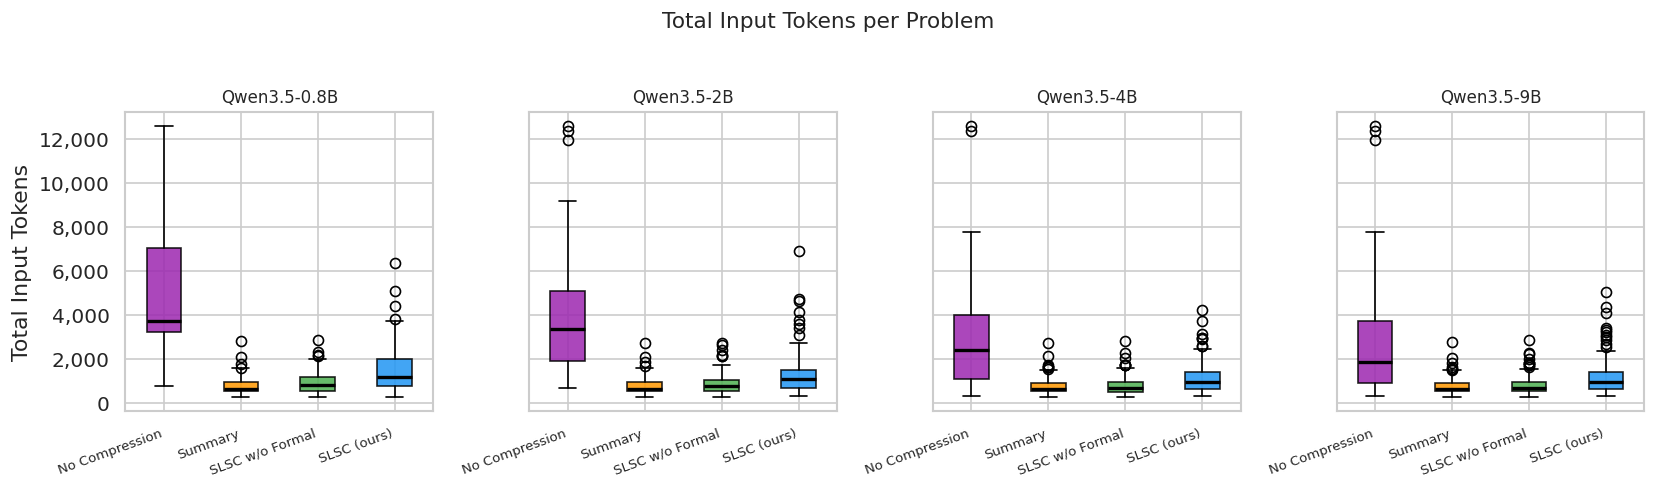

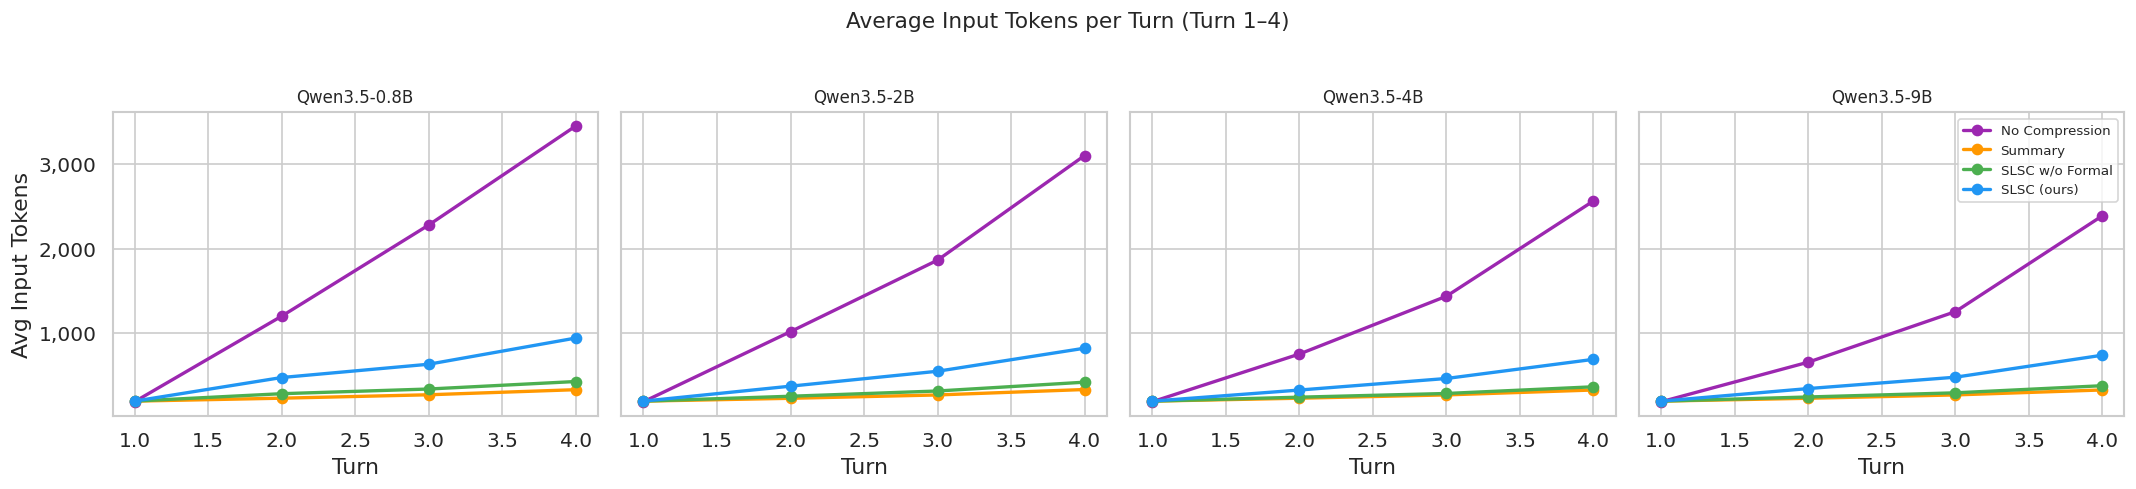

No Compression  SLSC (ours)  SLSC w/o Formal  Summary
Model        Turn                                                       
Qwen3.5-0.8B 1                188          195              195      195
             2               1200          474              283      230
             3               2278          631              338      270
             4               3450          941              427      330
Qwen3.5-2B   1                188          195              195      195
             2               1017          372              253      228
             3               1863          548              315      268
             4               3101          821              419      332
Qwen3.5-4B   1                188          195              195      195
             2                752          326              242      229
             3               1437          463              286      269
             4               2564          689              365      327
Qwen3.5-9B   1                188          195              195      195
             2                656          344              244      229
             3               1254          478              293      268
             4               2389          739              377      327

,No Compression,SLSC (ours),SLSC w/o Formal,Summary,Saving% SLSC (ours) vs NC
Model,,,,,
Qwen3.5-0.8B,4509.0,1533.0,913.0,768.0,66.0
Qwen3.5-2B,3864.0,1332.0,862.0,766.0,66.0
Qwen3.5-4B,3058.0,1153.0,806.0,766.0,62.0
Qwen3.5-9B,2767.0,1205.0,821.0,765.0,56.0


In [6]:
# ── 4a: Total input tokens per problem – boxplot ──────────────────────────
fig, axes = plt.subplots(1, n_models, figsize=(3.5*n_models, 4), sharey=True)
if n_models == 1: axes = [axes]

for ax, model in zip(axes, MODELS):
    sub = df_tok[df_tok["model"]==model]
    data, labels, colors = [], [], []
    for m in MODES:
        vals = sub[sub["mode"]==m]["total_input_tokens"].dropna().values
        if len(vals) == 0: continue
        data.append(vals); labels.append(MODE_LABELS[m]); colors.append(MODE_COLORS[m])
    bp = ax.boxplot(data, labels=labels, patch_artist=True,
                    medianprops=dict(color="black", linewidth=2))
    for patch, c in zip(bp["boxes"], colors):
        patch.set_facecolor(c); patch.set_alpha(0.85)
    ax.set_title(model, fontsize=10)
    ax.set_ylabel("Total Input Tokens" if ax==axes[0] else "")
    ax.set_xticklabels(labels, rotation=20, ha="right", fontsize=8)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"{int(v):,}"))

plt.suptitle("Total Input Tokens per Problem", y=1.02, fontsize=13)
plt.tight_layout(); plt.show()

# ── 4b: Per-turn average input tokens – line plot (turn 1–4 only) ─────────
turn_mean = (
    df_ttok[df_ttok["input_tokens"].notna() & (df_ttok["turn"] <= 4)]
    .groupby(["model","mode","turn"])["input_tokens"]
    .mean().reset_index()
)

fig, axes = plt.subplots(1, n_models, figsize=(4.5*n_models, 4), sharey=True)
if n_models == 1: axes = [axes]

for ax, model in zip(axes, MODELS):
    sub = turn_mean[turn_mean["model"]==model]
    for m in MODES:
        ms = sub[sub["mode"]==m]
        if ms.empty: continue
        ax.plot(ms["turn"], ms["input_tokens"], marker="o",
                label=MODE_LABELS[m], color=MODE_COLORS[m], linewidth=2)
    ax.set_title(model, fontsize=10)
    ax.set_xlabel("Turn")
    ax.set_ylabel("Avg Input Tokens" if ax==axes[0] else "")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"{int(v):,}"))
    if ax == axes[-1]: ax.legend(fontsize=8)

plt.suptitle("Average Input Tokens per Turn (Turn 1–4)", y=1.02, fontsize=13)
plt.tight_layout(); plt.show()

# ── table 4b: per-turn avg input tokens (turn 1–4) ────────────────────────
tbl4b = turn_mean.pivot_table(index=["model","turn"], columns="mode", values="input_tokens")
tbl4b.columns = [MODE_LABELS[c] for c in tbl4b.columns]
tbl4b.index.names = ["Model", "Turn"]
display(tbl4b.round(0).astype("Int64"))

# ── table 4a: mean total tokens + savings ─────────────────────────────────
tok_piv = (
    df_tok.groupby(["model","mode"])["total_input_tokens"]
    .mean().unstack("mode")
)
tok_piv.columns = [MODE_LABELS[c] for c in tok_piv.columns]
tok_piv.index.name = "Model"
nc_col = MODE_LABELS["no_compression"]
slsc_col = MODE_LABELS["slsc"]
if slsc_col in tok_piv.columns:
    tok_piv[f"Saving% {slsc_col} vs NC"] = (tok_piv[nc_col]-tok_piv[slsc_col])/tok_piv[nc_col]*100
display(tok_piv.round(0))

## 5. 类别准确率热力图

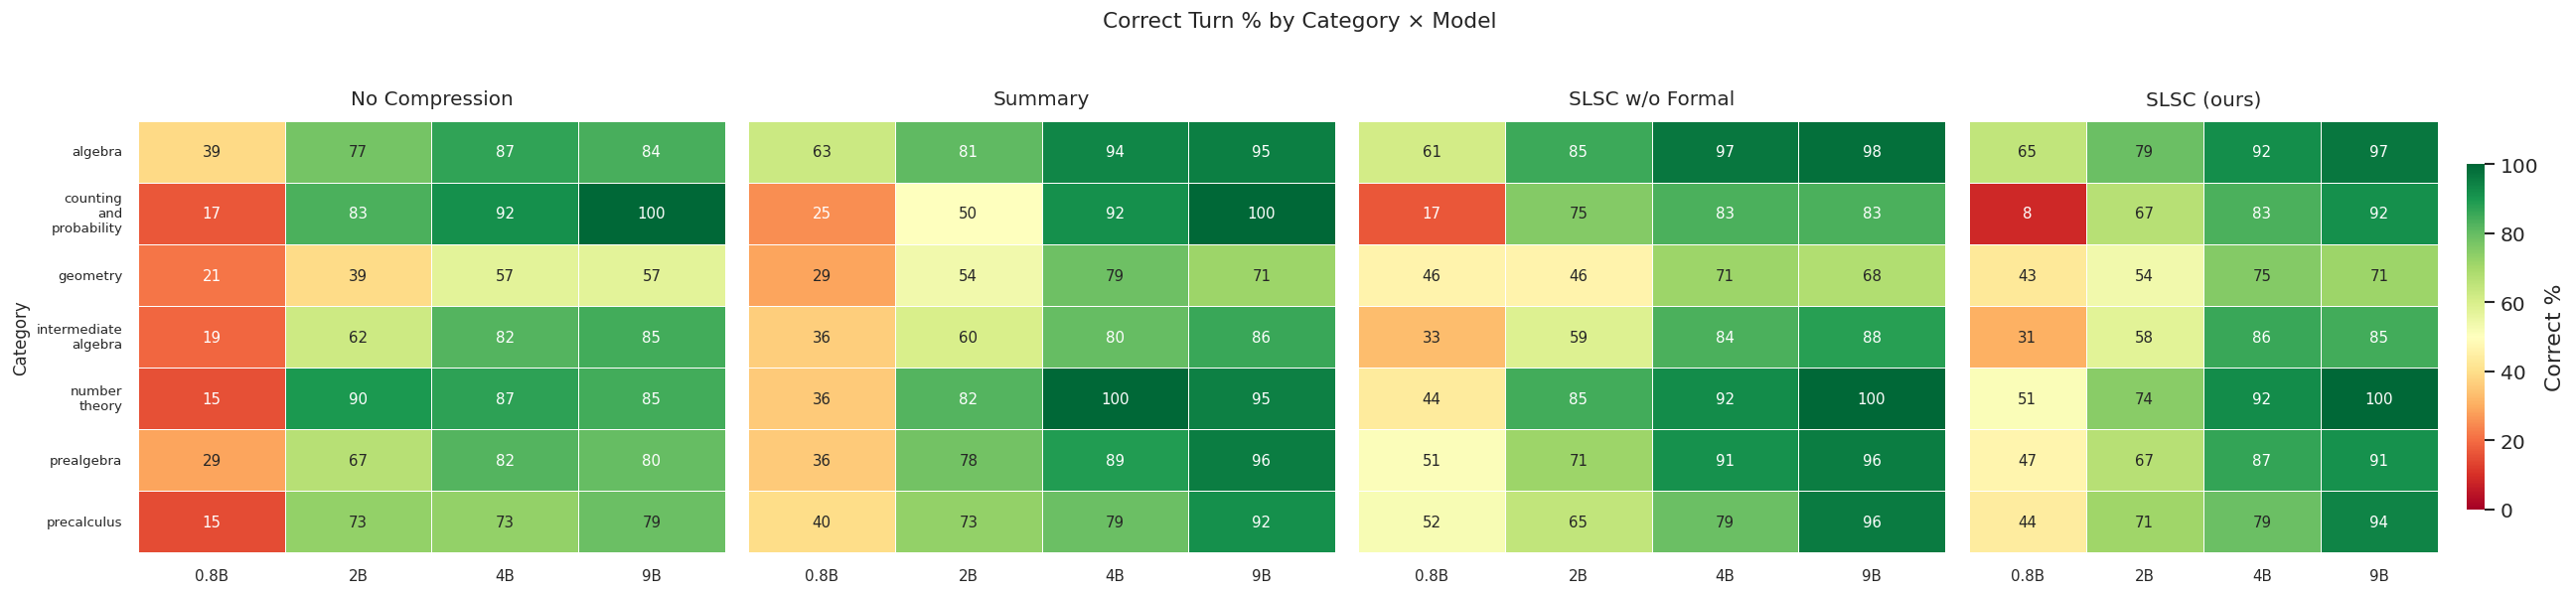

No Compression  SLSC (ours)  \
Category                 Model                                       
algebra                  Qwen3.5-0.8B            38.7         64.5   
                         Qwen3.5-2B              77.4         79.0   
                         Qwen3.5-4B              87.1         91.9   
                         Qwen3.5-9B              83.9         96.8   
counting_and_probability Qwen3.5-0.8B            16.7          8.3   
                         Qwen3.5-2B              83.3         66.7   
                         Qwen3.5-4B              91.7         83.3   
                         Qwen3.5-9B             100.0         91.7   
geometry                 Qwen3.5-0.8B            21.4         42.9   
                         Qwen3.5-2B              39.3         53.6   
                         Qwen3.5-4B              57.1         75.0   
                         Qwen3.5-9B              57.1         71.4   
intermediate_algebra     Qwen3.5-0.8B            18.8         30.6   
                         Qwen3.5-2B              62.4         57.6   
                         Qwen3.5-4B              82.4         85.9   
                         Qwen3.5-9B              84.7         84.7   
number_theory            Qwen3.5-0.8B            15.4         51.3   
                         Qwen3.5-2B              89.7         74.4   
                         Qwen3.5-4B              87.2         92.3   
                         Qwen3.5-9B              84.6        100.0   
prealgebra               Qwen3.5-0.8B            28.9         46.7   
                         Qwen3.5-2B              66.7         66.7   
                         Qwen3.5-4B              82.2         86.7   
                         Qwen3.5-9B              80.0         91.1   
precalculus              Qwen3.5-0.8B            14.6         43.8   
                         Qwen3.5-2B              72.9         70.8   
                         Qwen3.5-4B              72.9         79.2   
                         Qwen3.5-9B              79.2         93.8   

                                       SLSC w/o Formal  Summary  
Category                 Model                                   
algebra                  Qwen3.5-0.8B             61.3     62.7  
                         Qwen3.5-2B               85.5     80.6  
                         Qwen3.5-4B               96.8     93.5  
                         Qwen3.5-9B               98.4     95.2  
counting_and_probability Qwen3.5-0.8B             16.7     25.0  
                         Qwen3.5-2B               75.0     50.0  
                         Qwen3.5-4B               83.3     91.7  
                         Qwen3.5-9B               83.3    100.0  
geometry                 Qwen3.5-0.8B             46.4     28.6  
                         Qwen3.5-2B               46.4     53.6  
                         Qwen3.5-4B               71.4     78.6  
                         Qwen3.5-9B               67.9     71.4  
intermediate_algebra     Qwen3.5-0.8B             32.9     36.5  
                         Qwen3.5-2B               58.8     60.0  
                         Qwen3.5-4B               83.5     80.0  
                         Qwen3.5-9B               88.2     85.9  
number_theory            Qwen3.5-0.8B             43.6     35.9  
                         Qwen3.5-2B               84.6     82.1  
                         Qwen3.5-4B               92.3    100.0  
                         Qwen3.5-9B              100.0     94.9  
prealgebra               Qwen3.5-0.8B             51.1     35.6  
                         Qwen3.5-2B               71.1     77.8  
                         Qwen3.5-4B               91.1     88.9  
                         Qwen3.5-9B               95.6     95.6  
precalculus              Qwen3.5-0.8B             52.1     39.6  
                         Qwen3.5-2B               64.6     72.9  
                         Qwen3.5-4B               79.2     79.2  
                        

In [7]:
cat_acc = (
    df_turn.groupby(["model","mode","category"])["is_correct"]
    .agg(pct=lambda s: s.mean()*100)
    .reset_index()
)

heats = {}
for mode in MODES:
    sub = cat_acc[cat_acc["mode"]==mode]
    h = sub.pivot_table(index="category", columns="model", values="pct", fill_value=0)
    if not h.empty: heats[mode] = h

if heats:
    cats = sorted(set().union(*[h.index for h in heats.values()]))
    n_heat = len(heats)

    # 缩短 category 标签：去掉下划线、首字母大写
    cat_labels = {c: c.replace("_", "\n") for c in cats}
    # 缩短列名：去掉 "Qwen3.5-" 前缀
    col_labels = {m: m.replace("Qwen3.5-", "") for m in sorted(df_turn["model"].unique())}

    fig, axes = plt.subplots(1, n_heat, figsize=(5.5*n_heat, max(4, len(cats)*0.7)),
                             sharey=True)
    if n_heat == 1: axes = [axes]

    for ax, mode in zip(axes, MODES):
        if mode not in heats: continue
        h = heats[mode].reindex(cats, fill_value=0)
        h.index = [cat_labels[c] for c in h.index]
        h.columns = [col_labels[c] for c in h.columns]

        sns.heatmap(
            h, annot=True, fmt=".0f", cmap="RdYlGn", vmin=0, vmax=100,
            linewidths=0.5, ax=ax,
            cbar=(ax == axes[-1]),
            cbar_kws={"label": "Correct %", "shrink": 0.8} if ax == axes[-1] else {},
            annot_kws={"size": 9},
        )
        ax.set_title(MODE_LABELS[mode], fontsize=12, pad=10)
        ax.set_ylabel("Category" if ax == axes[0] else "", fontsize=10)
        ax.set_xlabel("")
        ax.tick_params(axis="x", labelsize=9, rotation=0)
        ax.tick_params(axis="y", labelsize=8, rotation=0)

    plt.suptitle("Correct Turn % by Category × Model", y=1.02, fontsize=13)
    plt.tight_layout()
    plt.show()

# ── table ──────────────────────────────────────────────────────────────────
tbl5 = cat_acc.pivot_table(index=["category","model"], columns="mode", values="pct")
tbl5.columns = [MODE_LABELS[c] for c in tbl5.columns]
tbl5.index.names = ["Category","Model"]
display(tbl5.round(1))

## 6. Token 效率散点图

横轴：平均总输入 token（log scale）；纵轴：准确率。右下角为高消耗低收益，左上角为高效区域。

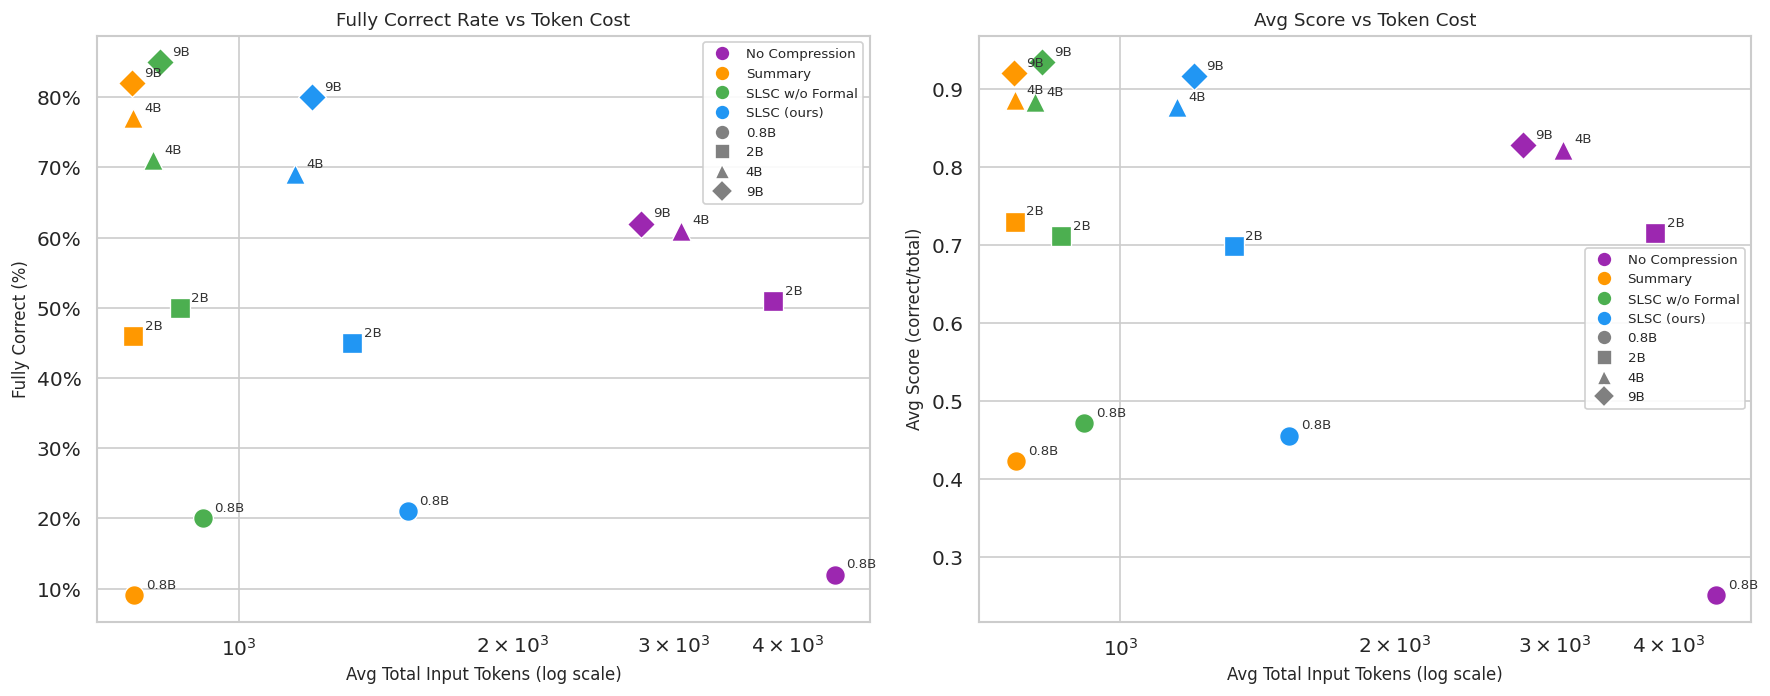

Avg Tokens  Fully Correct (%)  Avg Score
Model        Mode                                                     
Qwen3.5-0.8B No Compression         4509             12.000      0.251
             SLSC (ours)            1533             21.000      0.455
             SLSC w/o Formal         913             20.000      0.471
             Summary                 768              9.091      0.422
Qwen3.5-2B   No Compression         3864             51.000      0.714
             SLSC (ours)            1332             45.000      0.698
             SLSC w/o Formal         862             50.000      0.711
             Summary                 766             46.000      0.730
Qwen3.5-4B   No Compression         3058             61.000      0.822
             SLSC (ours)            1153             69.000      0.876
             SLSC w/o Formal         806             71.000      0.882
             Summary                 766             77.000      0.885
Qwen3.5-9B   No Compression         2767             62.000      0.828
             SLSC (ours)            1205             80.000      0.917
             SLSC w/o Formal         821             85.000      0.934
             Summary                 765             82.000      0.920

In [8]:
tok_agg = (
    df_tok.groupby(["model","mode"])["total_input_tokens"]
    .mean().reset_index().rename(columns={"total_input_tokens":"avg_tokens"})
)
acc_agg = (
    df_prob.groupby(["model","mode"])
    .agg(fc_pct=("all_correct", lambda x: x.mean()*100),
         avg_score=("score","mean"))
    .reset_index()
)
scatter_df = tok_agg.merge(acc_agg, on=["model","mode"])

MARKERS = ["o","s","^","D"]
model_marker = {m: MARKERS[i] for i,m in enumerate(sorted(scatter_df["model"].unique()))}

# ── chart ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, y_col, y_label, title in [
    (axes[0],"fc_pct",    "Fully Correct (%)",         "Fully Correct Rate vs Token Cost"),
    (axes[1],"avg_score", "Avg Score (correct/total)", "Avg Score vs Token Cost"),
]:
    for _, row in scatter_df.iterrows():
        ax.scatter(row["avg_tokens"], row[y_col],
                   color=MODE_COLORS[row["mode"]],
                   marker=model_marker[row["model"]],
                   s=140, zorder=3, edgecolors="white", linewidths=0.8)
        ax.annotate(row["model"].replace("Qwen3.5-",""),
                    xy=(row["avg_tokens"], row[y_col]),
                    xytext=(7, 4), textcoords="offset points",
                    fontsize=8, color="#333")

    ax.set_xscale("log")
    ax.set_xlabel("Avg Total Input Tokens (log scale)", fontsize=10)
    ax.set_ylabel(y_label, fontsize=10)
    ax.set_title(title, fontsize=11)
    if y_col == "fc_pct":
        ax.yaxis.set_major_formatter(mticker.PercentFormatter())

    mode_handles = [
        plt.Line2D([0],[0], marker="o", color="w", markerfacecolor=MODE_COLORS[m],
                   markersize=9, label=MODE_LABELS[m]) for m in MODES
    ]
    model_handles = [
        plt.Line2D([0],[0], marker=model_marker[m], color="w", markerfacecolor="grey",
                   markersize=9, label=m.replace("Qwen3.5-","")) for m in sorted(scatter_df["model"].unique())
    ]
    ax.legend(handles=mode_handles + model_handles,
              fontsize=8, loc="best", framealpha=0.9)

plt.tight_layout(); plt.show()

# ── table ──────────────────────────────────────────────────────────────────
tbl6 = scatter_df.copy()
tbl6["mode"] = tbl6["mode"].map(MODE_LABELS)
tbl6 = tbl6.rename(columns={"model":"Model","mode":"Mode",
                              "avg_tokens":"Avg Tokens","fc_pct":"Fully Correct (%)","avg_score":"Avg Score"})
tbl6 = tbl6.set_index(["Model","Mode"]).sort_index()
tbl6["Avg Tokens"] = tbl6["Avg Tokens"].round(0).astype(int)
display(tbl6.round(3))

## 7. 综合评估指标

- **Acc**：各轮平均正确率（%）
- **TU**：平均总输入 token 数
- **AccPerK**：每千 token 准确率 = 1000 × Acc / TU

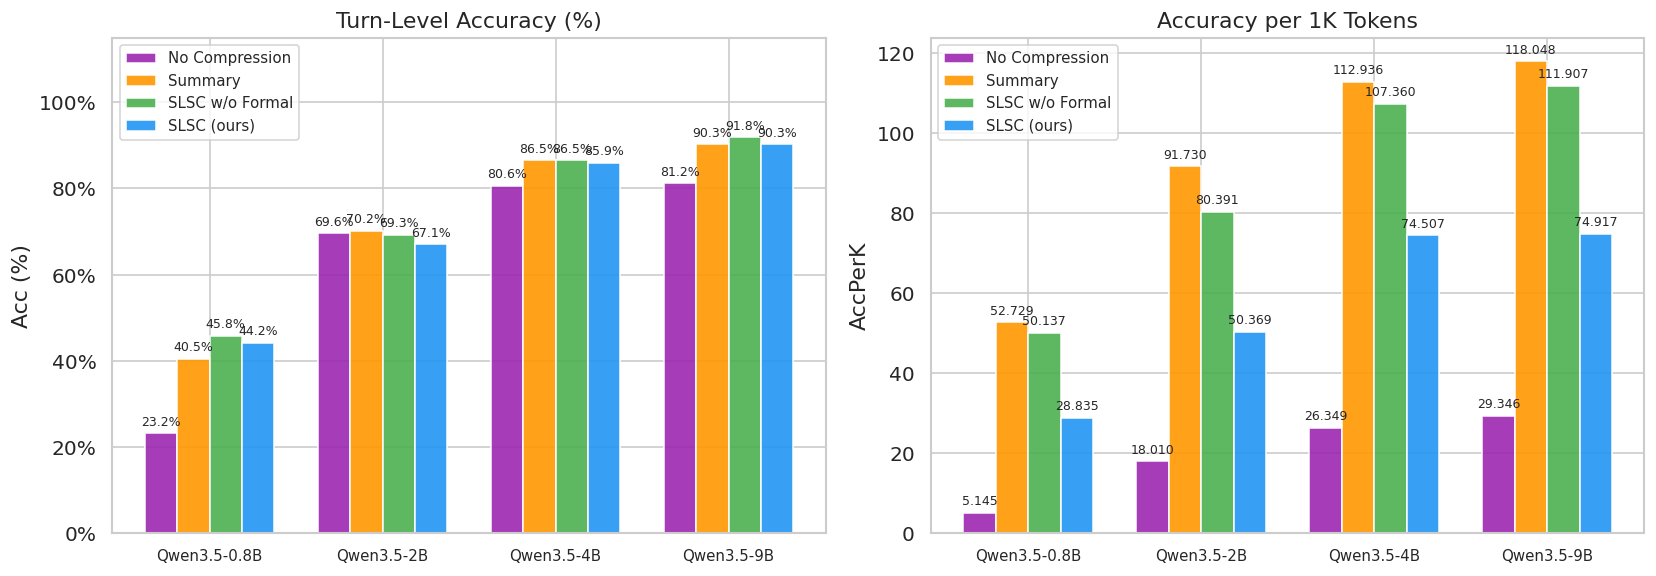

Acc (%) ↑  TU (tokens) ↓  AccPerK ↑
Model        Mode                                                
Qwen3.5-0.8B No Compression     23.1975           4509     5.1447
             SLSC (ours)        44.2006           1533    28.8346
             SLSC w/o Formal    45.7680            913    50.1370
             Summary            40.5063            768    52.7289
Qwen3.5-2B   No Compression     69.5925           3864    18.0103
             SLSC (ours)        67.0846           1332    50.3691
             SLSC w/o Formal    69.2790            862    80.3906
             Summary            70.2194            766    91.7302
Qwen3.5-4B   No Compression     80.5643           3058    26.3489
             SLSC (ours)        85.8934           1153    74.5072
             SLSC w/o Formal    86.5204            806   107.3600
             Summary            86.5204            766   112.9361
Qwen3.5-9B   No Compression     81.1912           2767    29.3458
             SLSC (ours)        90.2821           1205    74.9173
             SLSC w/o Formal    91.8495            821   111.9065
             Summary            90.2821            765   118.0483


跨模型均值：


,Acc (%) ↑,TU (tokens) ↓,AccPerK ↑
No Compression,63.6364,3549,19.7124
Summary,71.8821,766,93.8609
SLSC w/o Formal,73.3542,850,87.4485
SLSC (ours),71.8652,1306,57.1571


In [9]:
turn_acc_rate = (
    df_turn.groupby(["model","mode"])["is_correct"]
    .mean().mul(100).reset_index(name="acc")
)
tu_agg = (
    df_tok.groupby(["model","mode"])["total_input_tokens"]
    .mean().reset_index(name="tu")
)
comp = turn_acc_rate.merge(tu_agg, on=["model","mode"])
comp["acc_per_k"] = 1000 * comp["acc"] / comp["tu"]

# ── chart: AccPerK grouped bar ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, title, ylabel, fmt in [
    (axes[0], "acc",       "Turn-Level Accuracy (%)",    "Acc (%)",    "%.1f%%"),
    (axes[1], "acc_per_k", "Accuracy per 1K Tokens",     "AccPerK",    "%.3f"),
]:
    for i, mode in enumerate(MODES):
        sub = comp[comp["mode"]==mode].set_index("model")
        offset = (i - (n_modes-1)/2) * width
        vals = [sub.loc[m, col] if m in sub.index else 0 for m in MODELS]
        bars = ax.bar(x+offset, vals, width,
                      label=MODE_LABELS[mode], color=MODE_COLORS[mode],
                      edgecolor="white", alpha=0.9)
        ax.bar_label(bars, fmt=fmt, padding=3, fontsize=7.5)
    ax.set_xticks(x); ax.set_xticklabels(MODELS, fontsize=9)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    if col == "acc":
        ax.yaxis.set_major_formatter(mticker.PercentFormatter())
        ax.set_ylim(0, 115)
    ax.legend(fontsize=9)

plt.tight_layout(); plt.show()

# ── per-model table ────────────────────────────────────────────────────────
tbl7 = comp.copy()
tbl7["mode"] = tbl7["mode"].map(MODE_LABELS)
tbl7 = tbl7.rename(columns={"model":"Model","mode":"Mode",
                              "acc":"Acc (%) ↑","tu":"TU (tokens) ↓","acc_per_k":"AccPerK ↑"})
tbl7 = tbl7.set_index(["Model","Mode"]).sort_index()
tbl7["TU (tokens) ↓"] = tbl7["TU (tokens) ↓"].round(0).astype(int)
display(tbl7.round(4))

# ── cross-model mean ───────────────────────────────────────────────────────
print("\n跨模型均值：")
mean_tbl = (
    comp.groupby("mode")
    .agg({"acc":"mean","tu":"mean","acc_per_k":"mean"})
    .reindex(MODES)
)
mean_tbl.index = [MODE_LABELS[m] for m in mean_tbl.index]
mean_tbl.columns = ["Acc (%) ↑","TU (tokens) ↓","AccPerK ↑"]
mean_tbl["TU (tokens) ↓"] = mean_tbl["TU (tokens) ↓"].round(0).astype(int)
display(mean_tbl.round(4))

## Paper Tables

以下各 cell 对应论文 §4–§5 中各表格所需的精确数值。

In [10]:

# ── Table 1: Dataset turn-count distribution ──────────────────────────────
print("Table 1 — Turn-count distribution (n=100)")
print("-" * 45)
sample = df_prob[(df_prob["model"] == "Qwen3.5-4B") & (df_prob["mode"] == "no_compression")]
turn_dist = sample["num_turns"].value_counts().sort_index()
total = len(sample)
for t, c in turn_dist.items():
    print(f"  {t} turns  |  {c:3d}  |  {c/total*100:.1f}%")
print(f"  Total    |  {total:3d}  |  100.0%")


Table 1 — Turn-count distribution (n=100)
---------------------------------------------
  2 turns  |   13  |  13.0%
  3 turns  |   58  |  58.0%
  4 turns  |   26  |  26.0%
  5 turns  |    3  |  3.0%
  Total    |  100  |  100.0%


In [11]:

from scipy.stats import binomtest

def mcnemar_p(df, model, mode_a, mode_b):
    a = df[(df["model"] == model) & (df["mode"] == mode_a)].set_index("problem_id")["all_correct"]
    b = df[(df["model"] == model) & (df["mode"] == mode_b)].set_index("problem_id")["all_correct"]
    common = a.index.intersection(b.index)
    a, b = a[common].astype(bool), b[common].astype(bool)
    n10 = ((a == True) & (b == False)).sum()
    n01 = ((a == False) & (b == True)).sum()
    if n10 + n01 == 0:
        return 1.0
    return binomtest(int(n10), int(n10 + n01), 0.5).pvalue

# ── Table 2: Main results — Fully Correct Rate (FCR) ─────────────────────
MODELS_ORDER = ["Qwen3.5-0.8B", "Qwen3.5-2B", "Qwen3.5-4B", "Qwen3.5-9B"]

acc = (
    df_prob.groupby(["model", "mode"])
    .agg(n=("problem_id", "count"), fc=("all_correct", "sum"))
    .assign(fc_pct=lambda d: d["fc"] / d["n"] * 100)
    .reset_index()
)

rows = []
for model in MODELS_ORDER:
    def get_fc(m):
        sub = acc[(acc["model"] == model) & (acc["mode"] == m)]
        return sub["fc_pct"].values[0] if not sub.empty else float("nan")

    r = {m: get_fc(m) for m in MODES}

    def delta_sig(mode_b):
        delta = r.get(mode_b, float("nan")) - r.get("no_compression", float("nan"))
        p = mcnemar_p(df_prob, model, mode_b, "no_compression")
        sig = "†" if p < 0.05 else ""
        return f"{delta:+.1f}{sig}", f"{p:.4f}"

    d_sum,  p_sum  = delta_sig("summary")
    d_snf,  p_snf  = delta_sig("slsc_no_formal")
    d_slsc, p_slsc = delta_sig("slsc")

    rows.append({
        "Reasoner":          model,
        "No Compression":    f"{r.get('no_compression', 0):.1f}",
        "Summary":           f"{r.get('summary', float('nan')):.1f}",
        "SLSC w/o Formal":   f"{r.get('slsc_no_formal', float('nan')):.1f}",
        "SLSC + Lean":       f"{r.get('slsc', 0):.1f}",
        "Δ Summary":         d_sum,
        "Δ SLSC w/o Formal": d_snf,
        "Δ SLSC":            d_slsc,
        "p Summary":         p_sum,
        "p SLSC w/o Formal": p_snf,
        "p SLSC":            p_slsc,
    })

tbl_main = pd.DataFrame(rows).set_index("Reasoner")
print("Table 2 — Main Results: Fully Correct Rate (%)")
display(tbl_main)


Table 2 — Main Results: Fully Correct Rate (%)


,No Compression,Summary,SLSC w/o Formal,SLSC + Lean,Δ Summary,Δ SLSC w/o Formal,Δ SLSC,p Summary,p SLSC w/o Formal,p SLSC
Reasoner,,,,,,,,,,
Qwen3.5-0.8B,12.0,9.1,20.0,21.0,-2.9,+8.0,+9.0,0.8036,0.1338,0.0784
Qwen3.5-2B,51.0,46.0,50.0,45.0,-5.0,-1.0,-6.0,0.4583,1.0000,0.3616
Qwen3.5-4B,61.0,77.0,71.0,69.0,+16.0†,+10.0,+8.0,0.0037,0.0987,0.2005
Qwen3.5-9B,62.0,82.0,85.0,80.0,+20.0†,+23.0†,+18.0†,0.0005,0.0001,0.0009


In [12]:

# ── Table 3: Correct Turn Rate (CTR) ─────────────────────────────────────
turn_acc = (
    df_turn.groupby(["model", "mode"])["is_correct"]
    .agg(pct=lambda s: s.mean() * 100)
    .reset_index()
)

rows_ctr = []
for model in MODELS_ORDER:
    def get_ctr(m):
        sub = turn_acc[(turn_acc["model"] == model) & (turn_acc["mode"] == m)]
        return sub["pct"].values[0] if not sub.empty else float("nan")

    rows_ctr.append({
        "Reasoner":        model,
        "No Compression":  f"{get_ctr('no_compression'):.1f}",
        "Summary":         f"{get_ctr('summary'):.1f}",
        "SLSC w/o Formal": f"{get_ctr('slsc_no_formal'):.1f}",
        "SLSC + Lean":     f"{get_ctr('slsc'):.1f}",
    })

tbl_ctr = pd.DataFrame(rows_ctr).set_index("Reasoner")
print("Table 3 — Correct Turn Rate (%)")
display(tbl_ctr)


Table 3 — Correct Turn Rate (%)


,No Compression,Summary,SLSC w/o Formal,SLSC + Lean
Reasoner,,,,
Qwen3.5-0.8B,23.2,40.5,45.8,44.2
Qwen3.5-2B,69.6,70.2,69.3,67.1
Qwen3.5-4B,80.6,86.5,86.5,85.9
Qwen3.5-9B,81.2,90.3,91.8,90.3


In [13]:

# ── Table 5: Token usage (Qwen3.5-4B, paper focal model) ─────────────────
import math

MODEL_TOK = "Qwen3.5-4B"

ttok_m = df_ttok[df_ttok["model"] == MODEL_TOK]
tok_m  = df_tok[df_tok["model"] == MODEL_TOK]

avg_per_turn_in = ttok_m.groupby("mode")["input_tokens"].mean()
avg_total_in    = tok_m.groupby("mode")["total_input_tokens"].mean()
avg_b_in        = tok_m.groupby("mode")["total_agent_b_input_tokens"].mean()
avg_b_out       = tok_m.groupby("mode")["total_agent_b_output_tokens"].mean()
avg_combined    = tok_m.groupby("mode")["total_combined_tokens"].mean()

nc_total = avg_total_in.get("no_compression", 1)

rows_tok = []
for m in MODES:
    saving_total = (nc_total - avg_total_in.get(m, nc_total)) / nc_total * 100
    b_in  = avg_b_in.get(m, float("nan"))
    b_out = avg_b_out.get(m, float("nan"))
    rows_tok.append({
        "Condition":             MODE_LABELS[m],
        "A In (avg/turn)":       f"{avg_per_turn_in.get(m, 0):.0f}",
        "A Total In (avg/prob)": f"{avg_total_in.get(m, 0):.0f}",
        "B In (avg/prob)":       "—" if (math.isnan(b_in) or b_in == 0) else f"{b_in:.0f}",
        "B Out (avg/prob)":      "—" if (math.isnan(b_out) or b_out == 0) else f"{b_out:.0f}",
        "Combined (avg/prob)":   f"{avg_combined.get(m, 0):.0f}",
        "Saving (A In) vs FH":   "—" if m == "no_compression" else f"{saving_total:.1f}%",
    })

tbl_tok = pd.DataFrame(rows_tok).set_index("Condition")
print(f"Table 5 — Token usage at {MODEL_TOK} scale")
display(tbl_tok)

print("\nAll models — avg token breakdown per problem:")
rows_all = []
for model in MODELS_ORDER:
    tok_mm = df_tok[df_tok["model"] == model]
    avg_t  = tok_mm.groupby("mode")["total_input_tokens"].mean()
    avg_b  = tok_mm.groupby("mode")["total_agent_b_input_tokens"].mean()
    nc_t   = avg_t.get("no_compression", 1)
    rows_all.append({
        "Model":             model,
        "No Compression":    f"{avg_t.get('no_compression', 0):.0f}",
        "Summary":           f"{avg_t.get('summary', 0):.0f}",
        "SLSC w/o Formal":   f"{avg_t.get('slsc_no_formal', 0):.0f}",
        "SLSC + Lean":       f"{avg_t.get('slsc', 0):.0f}",
        "Saving Summary":    f"{(nc_t - avg_t.get('summary', nc_t)) / nc_t * 100:.1f}%",
        "Saving SLSC w/o F": f"{(nc_t - avg_t.get('slsc_no_formal', nc_t)) / nc_t * 100:.1f}%",
        "Saving SLSC":       f"{(nc_t - avg_t.get('slsc', nc_t)) / nc_t * 100:.1f}%",
    })
display(pd.DataFrame(rows_all).set_index("Model"))


Table 5 — Token usage at Qwen3.5-4B scale


,A In (avg/turn),A Total In (avg/prob),B In (avg/prob),B Out (avg/prob),Combined (avg/prob),Saving (A In) vs FH
Condition,,,,,,
No Compression,958,3058,—,—,6083,—
Summary,240,766,1035,84,3108,74.9%
SLSC w/o Formal,253,806,2287,468,4798,73.6%
SLSC (ours),361,1153,3710,852,6951,62.3%



All models — avg token breakdown per problem:


,No Compression,Summary,SLSC w/o Formal,SLSC + Lean,Saving Summary,Saving SLSC w/o F,Saving SLSC
Model,,,,,,,
Qwen3.5-0.8B,4509,768,913,1533,83.0%,79.8%,66.0%
Qwen3.5-2B,3864,766,862,1332,80.2%,77.7%,65.5%
Qwen3.5-4B,3058,766,806,1153,74.9%,73.6%,62.3%
Qwen3.5-9B,2767,765,821,1205,72.4%,70.3%,56.4%


In [14]:

# ── Per-turn accuracy breakdown (Qwen3.5-4B) — supports §5.4 analysis ────
MODEL_PT = "Qwen3.5-4B"

turn_pos = (
    df_turn[df_turn["model"] == MODEL_PT]
    .groupby(["mode", "turn"])["is_correct"]
    .agg(pct=lambda s: s.mean() * 100, n="count")
    .reset_index()
)

MODE_COL_LABELS = {
    "no_compression": "No Compression",
    "summary":        "Summary",
    "slsc_no_formal": "SLSC w/o Formal",
    "slsc":           "SLSC + Lean",
}

rows_pt = []
for turn_idx in sorted(turn_pos["turn"].unique()):
    row = {"Turn": int(turn_idx)}
    for m in MODES:
        sub = turn_pos[(turn_pos["mode"] == m) & (turn_pos["turn"] == turn_idx)]
        if not sub.empty:
            row[MODE_COL_LABELS[m]] = f"{sub['pct'].values[0]:.1f}% (n={int(sub['n'].values[0])})"
    rows_pt.append(row)

tbl_pt = pd.DataFrame(rows_pt).set_index("Turn")
print(f"Per-turn Correct Turn Rate — {MODEL_PT}")
display(tbl_pt)


Per-turn Correct Turn Rate — Qwen3.5-4B


,No Compression,Summary,SLSC w/o Formal,SLSC + Lean
Turn,,,,
1,84.0% (n=100),91.0% (n=100),91.0% (n=100),91.0% (n=100)
2,81.0% (n=100),88.0% (n=100),85.0% (n=100),83.0% (n=100)
3,80.5% (n=87),87.4% (n=87),87.4% (n=87),87.4% (n=87)
4,69.0% (n=29),69.0% (n=29),75.9% (n=29),75.9% (n=29)
5,66.7% (n=3),33.3% (n=3),66.7% (n=3),66.7% (n=3)


### Tables requiring manual annotation

以下三张表需要人工标注，无法从 `results_v5/` 自动计算：

| 表格 | 内容 | 所需工作 |
|------|------|----------|
| **Table 4** (Lean quality) | 50 条随机 Lean 输出的质量维度（语法合法、语义对齐、幻觉符号、类型检查通过） | 从 `logs/Qwen3.5-4B_slsc.log` 中随机抽取 50 条 Lean 输出，人工逐条标注 |
| **Table 6** (FH failure modes) | 30 道 Full History 失败但 SLSC 成功的题目的失败原因分布 | 对比 `Qwen3.5-4B_model_judged.jsonl` 与 `Qwen3.5-4B_slsc_judged.jsonl`，筛出差异题目后人工分类 |
| **Table 7** (SLSC failure modes) | SLSC 失败但 Full History 成功的题目的失败原因分布（2B scale） | 对比 `Qwen3.5-2B_slsc_judged.jsonl` 与 `Qwen3.5-2B_model_judged.jsonl`，筛出差异题目后人工分类 |

下面的 cell 输出差异题目列表，供人工标注使用。

In [15]:

# ── Helper: problems where condition A fails but condition B succeeds ──────
def diff_problems(df_prob, model, fail_mode, succeed_mode):
    a = df_prob[(df_prob["model"] == model) & (df_prob["mode"] == fail_mode)].set_index("problem_id")["all_correct"]
    b = df_prob[(df_prob["model"] == model) & (df_prob["mode"] == succeed_mode)].set_index("problem_id")["all_correct"]
    a = a[~a.index.duplicated(keep="first")].astype(bool)
    b = b[~b.index.duplicated(keep="first")].astype(bool)
    common = a.index.intersection(b.index)
    return sorted([pid for pid in common if not a[pid] and b[pid]])

# Table 6: FH fails, SLSC succeeds (4B)
fh_fail_4b = diff_problems(df_prob, "Qwen3.5-4B", "no_compression", "slsc")
print(f"Table 6 candidates — FH fails, SLSC succeeds (Qwen3.5-4B): {len(fh_fail_4b)} problems")
for pid in fh_fail_4b:
    print(f"  {pid}")

print()

# Table 7: SLSC fails, FH succeeds (2B)
slsc_fail_2b = diff_problems(df_prob, "Qwen3.5-2B", "slsc", "no_compression")
print(f"Table 7 candidates — SLSC fails, FH succeeds (Qwen3.5-2B): {len(slsc_fail_2b)} problems")
for pid in slsc_fail_2b:
    print(f"  {pid}")

print()

# Additional: FH fails, Summary succeeds (4B)
fh_fail_sum_4b = diff_problems(df_prob, "Qwen3.5-4B", "no_compression", "summary")
print(f"FH fails, Summary succeeds (Qwen3.5-4B): {len(fh_fail_sum_4b)} problems")

# Additional: FH fails, SLSC w/o Formal succeeds (4B)
fh_fail_snf_4b = diff_problems(df_prob, "Qwen3.5-4B", "no_compression", "slsc_no_formal")
print(f"FH fails, SLSC w/o Formal succeeds (Qwen3.5-4B): {len(fh_fail_snf_4b)} problems")


Table 6 candidates — FH fails, SLSC succeeds (Qwen3.5-4B): 19 problems
  test/algebra/114.json
  test/algebra/2264.json
  test/algebra/305.json
  test/algebra/769.json
  test/geometry/434.json
  test/geometry/538.json
  test/geometry/711.json
  test/intermediate_algebra/128.json
  test/intermediate_algebra/1898.json
  test/intermediate_algebra/515.json
  test/intermediate_algebra/956.json
  test/number_theory/1000.json
  test/number_theory/1002.json
  test/prealgebra/1640.json
  test/prealgebra/465.json
  test/precalculus/1291.json
  test/precalculus/580.json
  test/precalculus/675.json
  test/precalculus/927.json

Table 7 candidates — SLSC fails, FH succeeds (Qwen3.5-2B): 18 problems
  test/algebra/1282.json
  test/algebra/1547.json
  test/algebra/2427.json
  test/counting_and_probability/134.json
  test/counting_and_probability/159.json
  test/intermediate_algebra/1508.json
  test/intermediate_algebra/1797.json
  test/intermediate_algebra/776.json
  test/intermediate_algebra/991.json

## 8. Level ≥ 3 且 Turn ≥ 3 子集分析

从 MATH-500 数据集中筛选出难度 Level 3、4、5 **且** 对话轮数 ≥ 3 的题目，重新计算各项指标。

In [16]:

# ── 构建 problem_id → level 映射 ───────────────────────────────────────────
from datasets import load_dataset

math500 = load_dataset("HuggingFaceH4/MATH-500", split="test",
                       cache_dir="/root/.cache/huggingface")
level_map = {item["unique_id"]: item["level"] for item in math500}
print(f"Level distribution: { {k: sum(1 for v in level_map.values() if v==k) for k in sorted(set(level_map.values()))} }")

# ── 筛选 level ≥ 3 ──────────────────────────────────────────────────────────
HARD_LEVELS = {3, 4, 5}
hard_pids   = {pid for pid, lv in level_map.items() if lv in HARD_LEVELS}

# ── 筛选 num_turns ≥ 3（取 no_compression 模式的 num_turns 作为题目的轮数基准）──
# 每道题在不同 mode 下轮数可能不同，这里以 no_compression 模式为基准筛选题目 ID
turns_per_prob = (
    df_prob[df_prob["mode"] == "no_compression"]
    .groupby("problem_id")["num_turns"].first()
)
long_pids = set(turns_per_prob[turns_per_prob >= 3].index)

# ── 双重过滤 ────────────────────────────────────────────────────────────────
hard_long_pids = hard_pids & long_pids

df_prob_h = df_prob[df_prob["problem_id"].isin(hard_long_pids)].copy()
df_turn_h = df_turn[df_turn["problem_id"].isin(hard_long_pids)].copy()
df_tok_h  = df_tok[df_tok["problem_id"].isin(hard_long_pids)].copy()

n_hard = df_prob_h[df_prob_h["mode"] == "no_compression"]["problem_id"].nunique()
print(f"\n筛选后题目数 (Level≥3 & Turn≥3): {n_hard}  |  prob rows: {len(df_prob_h)}  |  turn rows: {len(df_turn_h)}")
lv_dist = df_prob_h[df_prob_h["mode"] == "no_compression"]["problem_id"].map(level_map).value_counts().sort_index().to_dict()
print("Level breakdown:", lv_dist)
turn_dist = df_prob_h[df_prob_h["mode"] == "no_compression"]["num_turns"].value_counts().sort_index().to_dict()
print("Turn breakdown:", turn_dist)


Level distribution: {1: 43, 2: 90, 3: 105, 4: 128, 5: 134}

筛选后题目数 (Level≥3 & Turn≥3): 67  |  prob rows: 1072  |  turn rows: 3696
Level breakdown: {3: 36, 4: 68, 5: 164}
Turn breakdown: {3: 160, 4: 96, 5: 12}


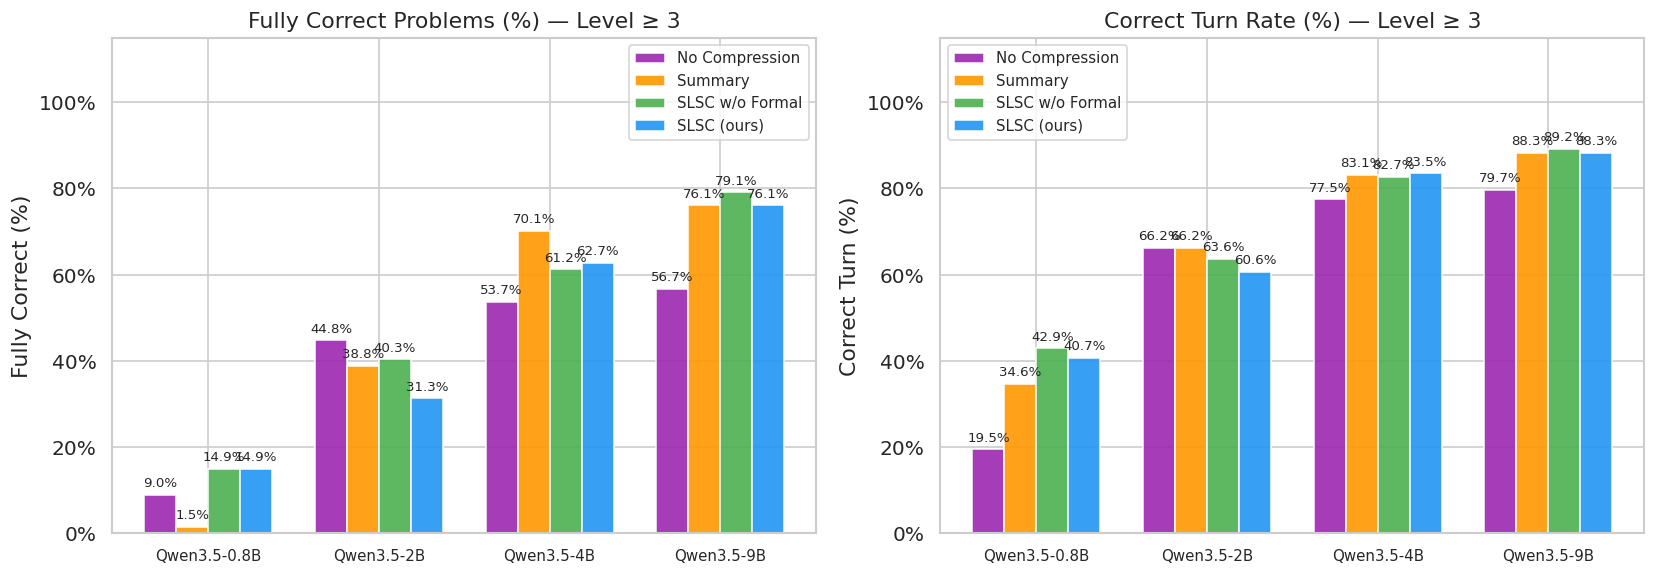

,No Compression,SLSC (ours),SLSC w/o Formal,Summary,Δ SLSC (ours) − NC
Model,,,,,
Qwen3.5-0.8B,9.0,14.9,14.9,1.5,6.0
Qwen3.5-2B,44.8,31.3,40.3,38.8,-13.4
Qwen3.5-4B,53.7,62.7,61.2,70.1,9.0
Qwen3.5-9B,56.7,76.1,79.1,76.1,19.4


In [17]:

# ── 8a. 整体准确率对比（Level ≥ 3）────────────────────────────────────────
acc_h = (
    df_prob_h.groupby(["model", "mode"])
    .agg(n=("problem_id", "count"), fc=("all_correct", "sum"))
    .assign(fc_pct=lambda d: d["fc"] / d["n"] * 100)
    .reset_index()
)
turn_acc_h = (
    df_turn_h.groupby(["model", "mode"])["is_correct"]
    .agg(pct=lambda s: s.mean() * 100)
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, df_src, col, title, ylabel in [
    (axes[0], acc_h,      "fc_pct", "Fully Correct Problems (%) — Level ≥ 3", "Fully Correct (%)"),
    (axes[1], turn_acc_h, "pct",    "Correct Turn Rate (%) — Level ≥ 3",      "Correct Turn (%)"),
]:
    for i, mode in enumerate(MODES):
        sub = df_src[df_src["mode"] == mode].set_index("model")
        offset = (i - (n_modes - 1) / 2) * width
        vals = [sub.loc[m, col] if m in sub.index else 0 for m in MODELS]
        bars = ax.bar(x + offset, vals, width,
                      label=MODE_LABELS[mode], color=MODE_COLORS[mode],
                      edgecolor="white", alpha=0.9)
        ax.bar_label(bars, fmt="%.1f%%", padding=3, fontsize=8)
    ax.set_xticks(x); ax.set_xticklabels(MODELS, fontsize=9)
    ax.set_ylabel(ylabel); ax.set_ylim(0, 115)
    ax.set_title(title)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter())
    ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

# ── 表格 ──────────────────────────────────────────────────────────────────
tbl_h = acc_h.pivot_table(index="model", columns="mode", values="fc_pct")
tbl_h.columns = [MODE_LABELS[c] for c in tbl_h.columns]
tbl_h.index.name = "Model"
nc_col = MODE_LABELS["no_compression"]
slsc_col = MODE_LABELS["slsc"]
if slsc_col in tbl_h.columns:
    tbl_h[f"Δ {slsc_col} − NC"] = tbl_h[slsc_col] - tbl_h[nc_col]
display(tbl_h.round(1))


In [18]:

# ── 8b. Main Results Table（Level ≥ 3）with McNemar test ─────────────────
from scipy.stats import binomtest

def mcnemar_p_h(model, mode_a, mode_b):
    a = df_prob_h[(df_prob_h["model"] == model) & (df_prob_h["mode"] == mode_a)].set_index("problem_id")["all_correct"]
    b = df_prob_h[(df_prob_h["model"] == model) & (df_prob_h["mode"] == mode_b)].set_index("problem_id")["all_correct"]
    common = a.index.intersection(b.index)
    a, b = a[common].astype(bool), b[common].astype(bool)
    n10 = ((a == True)  & (b == False)).sum()
    n01 = ((a == False) & (b == True)).sum()
    if n10 + n01 == 0:
        return 1.0
    return binomtest(int(n10), int(n10 + n01), 0.5).pvalue

rows_h = []
for model in MODELS_ORDER:
    def get_fc(m):
        sub = acc_h[(acc_h["model"] == model) & (acc_h["mode"] == m)]
        return sub["fc_pct"].values[0] if not sub.empty else float("nan")

    r = {m: get_fc(m) for m in MODES}

    def delta_sig(mode_b):
        delta = r.get(mode_b, float("nan")) - r.get("no_compression", float("nan"))
        p = mcnemar_p_h(model, mode_b, "no_compression")
        sig = "†" if p < 0.05 else ""
        return f"{delta:+.1f}{sig}", f"{p:.4f}"

    d_sum,  p_sum  = delta_sig("summary")
    d_snf,  p_snf  = delta_sig("slsc_no_formal")
    d_slsc, p_slsc = delta_sig("slsc")

    rows_h.append({
        "Reasoner":          model,
        "No Compression":    f"{r.get('no_compression', 0):.1f}",
        "Summary":           f"{r.get('summary', float('nan')):.1f}",
        "SLSC w/o Formal":   f"{r.get('slsc_no_formal', float('nan')):.1f}",
        "SLSC + Lean":       f"{r.get('slsc', 0):.1f}",
        "Δ Summary":         d_sum,
        "Δ SLSC w/o Formal": d_snf,
        "Δ SLSC":            d_slsc,
        "p Summary":         p_sum,
        "p SLSC w/o Formal": p_snf,
        "p SLSC":            p_slsc,
    })

tbl_main_h = pd.DataFrame(rows_h).set_index("Reasoner")
print("Main Results (Level ≥ 3): Fully Correct Rate (%)")
display(tbl_main_h)

# ── Correct Turn Rate ──────────────────────────────────────────────────────
rows_ctr_h = []
for model in MODELS_ORDER:
    def get_ctr(m):
        sub = turn_acc_h[(turn_acc_h["model"] == model) & (turn_acc_h["mode"] == m)]
        return sub["pct"].values[0] if not sub.empty else float("nan")
    rows_ctr_h.append({
        "Reasoner":        model,
        "No Compression":  f"{get_ctr('no_compression'):.1f}",
        "Summary":         f"{get_ctr('summary'):.1f}",
        "SLSC w/o Formal": f"{get_ctr('slsc_no_formal'):.1f}",
        "SLSC + Lean":     f"{get_ctr('slsc'):.1f}",
    })
print("\nCorrect Turn Rate (Level ≥ 3)")
display(pd.DataFrame(rows_ctr_h).set_index("Reasoner"))


Main Results (Level ≥ 3): Fully Correct Rate (%)


,No Compression,Summary,SLSC w/o Formal,SLSC + Lean,Δ Summary,Δ SLSC w/o Formal,Δ SLSC,p Summary,p SLSC w/o Formal,p SLSC
Reasoner,,,,,,,,,,
Qwen3.5-0.8B,9.0,1.5,14.9,14.9,-7.5,+6.0,+6.0,0.1250,0.3438,0.3438
Qwen3.5-2B,44.8,38.8,40.3,31.3,-6.0,-4.5,-13.4,0.4807,0.6291,0.0931
Qwen3.5-4B,53.7,70.1,61.2,62.7,+16.4†,+7.5,+9.0,0.0192,0.3833,0.2863
Qwen3.5-9B,56.7,76.1,79.1,76.1,+19.4†,+22.4†,+19.4†,0.0146,0.0059,0.0072



Correct Turn Rate (Level ≥ 3)


,No Compression,Summary,SLSC w/o Formal,SLSC + Lean
Reasoner,,,,
Qwen3.5-0.8B,19.5,34.6,42.9,40.7
Qwen3.5-2B,66.2,66.2,63.6,60.6
Qwen3.5-4B,77.5,83.1,82.7,83.5
Qwen3.5-9B,79.7,88.3,89.2,88.3


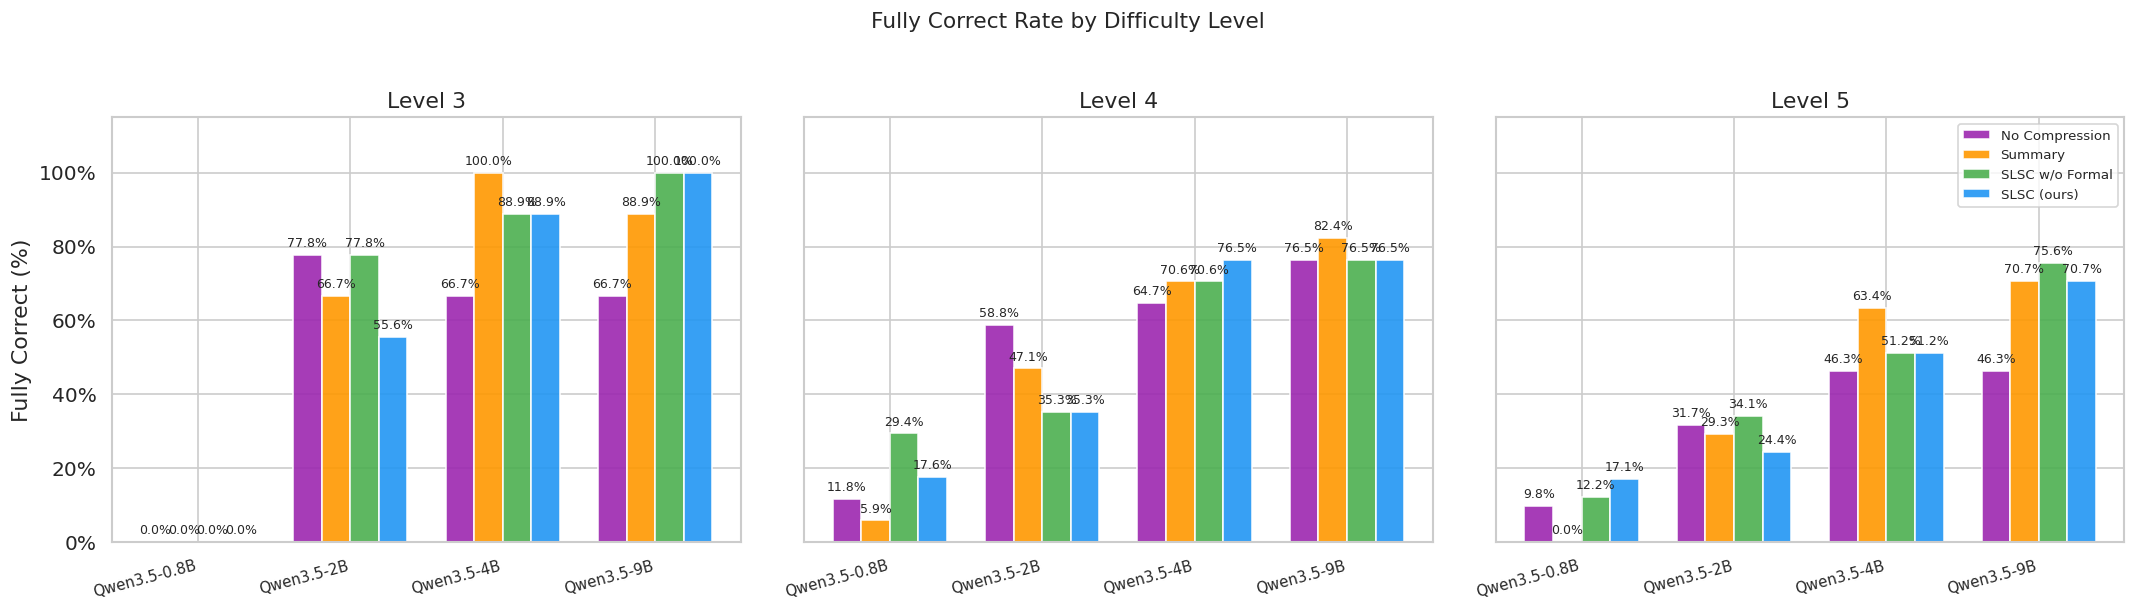

No Compression  SLSC (ours)  SLSC w/o Formal  Summary
Level Model                                                              
3     Qwen3.5-0.8B             0.0          0.0              0.0      0.0
      Qwen3.5-2B              77.8         55.6             77.8     66.7
      Qwen3.5-4B              66.7         88.9             88.9    100.0
      Qwen3.5-9B              66.7        100.0            100.0     88.9
4     Qwen3.5-0.8B            11.8         17.6             29.4      5.9
      Qwen3.5-2B              58.8         35.3             35.3     47.1
      Qwen3.5-4B              64.7         76.5             70.6     70.6
      Qwen3.5-9B              76.5         76.5             76.5     82.4
5     Qwen3.5-0.8B             9.8         17.1             12.2      0.0
      Qwen3.5-2B              31.7         24.4             34.1     29.3
      Qwen3.5-4B              46.3         51.2             51.2     63.4
      Qwen3.5-9B              46.3         70.7             75.6     70.7

In [19]:

# ── 8c. 按 Level 细分的 FCR（Level 3 / 4 / 5 分开看）────────────────────
df_prob_h2 = df_prob_h.copy()
df_prob_h2["level"] = df_prob_h2["problem_id"].map(level_map)

acc_by_lv = (
    df_prob_h2.groupby(["level", "model", "mode"])
    .agg(n=("problem_id", "count"), fc=("all_correct", "sum"))
    .assign(fc_pct=lambda d: d["fc"] / d["n"] * 100)
    .reset_index()
)

LEVELS = [3, 4, 5]
fig, axes = plt.subplots(1, len(LEVELS), figsize=(6 * len(LEVELS), 5), sharey=True)

for ax, lv in zip(axes, LEVELS):
    sub_lv = acc_by_lv[acc_by_lv["level"] == lv]
    for i, mode in enumerate(MODES):
        sub = sub_lv[sub_lv["mode"] == mode].set_index("model")
        offset = (i - (n_modes - 1) / 2) * width
        vals = [sub.loc[m, "fc_pct"] if m in sub.index else 0 for m in MODELS]
        bars = ax.bar(x + offset, vals, width,
                      label=MODE_LABELS[mode], color=MODE_COLORS[mode],
                      edgecolor="white", alpha=0.9)
        ax.bar_label(bars, fmt="%.1f%%", padding=3, fontsize=7.5)
    ax.set_xticks(x); ax.set_xticklabels(MODELS, fontsize=9, rotation=15, ha="right")
    ax.set_ylabel("Fully Correct (%)" if ax == axes[0] else "")
    ax.set_ylim(0, 115)
    ax.set_title(f"Level {lv}")
    ax.yaxis.set_major_formatter(mticker.PercentFormatter())
    if ax == axes[-1]:
        ax.legend(fontsize=8)

plt.suptitle("Fully Correct Rate by Difficulty Level", y=1.02, fontsize=13)
plt.tight_layout(); plt.show()

# ── 表格 ──────────────────────────────────────────────────────────────────
tbl_lv = acc_by_lv.pivot_table(index=["level", "model"], columns="mode", values="fc_pct")
tbl_lv.columns = [MODE_LABELS[c] for c in tbl_lv.columns]
tbl_lv.index.names = ["Level", "Model"]
display(tbl_lv.round(1))
